# Point Source Aperture Photometry

## Import Functions

In [18]:
import os
import sys
import time
import numpy as np
import pandas as pd
import glob as glob
import tarfile
import urllib.request
import gc
#import jwst
#from jwst.datamodels import ImageModel
from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import (ZScaleInterval, SqrtStretch, ImageNormalize)
from astropy.visualization import simple_norm
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units as u
import re
from photutils.detection import DAOStarFinder
from photutils.background import MMMBackground, MADStdBackgroundRMS, Background2D
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry

## Import Plotting Functions

In [19]:
%matplotlib inline
from matplotlib import style, pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker

plt.rcParams['image.cmap'] = 'viridis'
plt.rcParams['image.origin'] = 'lower'
plt.rcParams['axes.titlesize'] = plt.rcParams['axes.labelsize'] = 30
plt.rcParams['xtick.labelsize'] = plt.rcParams['ytick.labelsize'] = 30

font1 = {'family': 'helvetica', 'color': 'black', 'weight': 'normal', 'size': '6'}
font2 = {'family': 'helvetica', 'color': 'black', 'weight': 'normal', 'size': '12'}

## Load Images and create some useful dictionaries

We load all the images and we create a dictionary that contains all of them, divided by detectors and filters. This is useful to check which detectors and filters are available and to decide if we want to perform the photometry on all of them or only on a subset 

In [20]:
dict_images = {'MULTIPLE': {}}

dict_filter_short = {}
dict_filter_long = {}

ff_short = []
det_short = []
det_long = []
ff_long = []
detlist_short = []
detlist_long = []
filtlist_short = []
filtlist_long = []


In [21]:
images_dir = 'C:/Users/Observatory/Exo/Data/Standard-stars/SA-110340/photometry'
images = sorted(glob.glob(os.path.join(images_dir, "*.fits")))
#print (images)

In [22]:
from astropy.io import fits
import os

# Dictionary to store image metadata
dict_images = {}

for image in images:
    try:
        im = fits.open(image)
        dict_images[os.path.basename(image)] = {
            'path': image,
            'header': im[0].header,
            'data': im[0].data,
        }
        im.close()
    except Exception as e:
        print(f"Error loading {image}: {e}")

print(f"\n Loaded {len(dict_images)} images successfully.")



 Loaded 5 images successfully.


In [23]:
import os
import glob
from astropy.io import fits

# Define your image directory
images_dir = 'C:/Users/Observatory/Exo/Data/Standard-stars/SA-110340/photometry'

# Find all FITS files (handles multiple extensions just in case)
images = []
for ext in ['*.fits']:
    images.extend(glob.glob(os.path.join(images_dir, ext)))

# Remove duplicates if any (e.g., if one file matched multiple extensions)
images = sorted(list(set(images)))

print(f" Found {len(images)} FITS files.")

# Dictionary to store image metadata
dict_images = {}

# Load all images and store in dictionary
for image in images:
    try:
        im = fits.open(image)
        dict_images[os.path.basename(image)] = {
            'path': image,
            'header': im[0].header,
            'data': im[0].data,
        }
        im.close()
    except Exception as e:
        print(f" Error loading {image}: {e}")

print(f" Loaded {len(dict_images)} images successfully.")


 Found 5 FITS files.
 Loaded 5 images successfully.


In [24]:
# Dictionary of filter info (initial placeholders for commissioning phase)

filter_data = {
    'u': {'psf_fwhm': None, 'zp_AB': None},
    'g': {'psf_fwhm': None, 'zp_AB': None},
    'r': {'psf_fwhm': None, 'zp_AB': None},
    'i': {'psf_fwhm': None, 'zp_AB': None},
}

## Example access for a given filter:
#filter_name = 'g'
#psf = filter_data[filter_name]['psf_fwhm']
#zp_AB = filter_data[filter_name]['zp_AB']


## Display the images

To check that our images do not present artifacts and can be used in the analysis, we display them. 

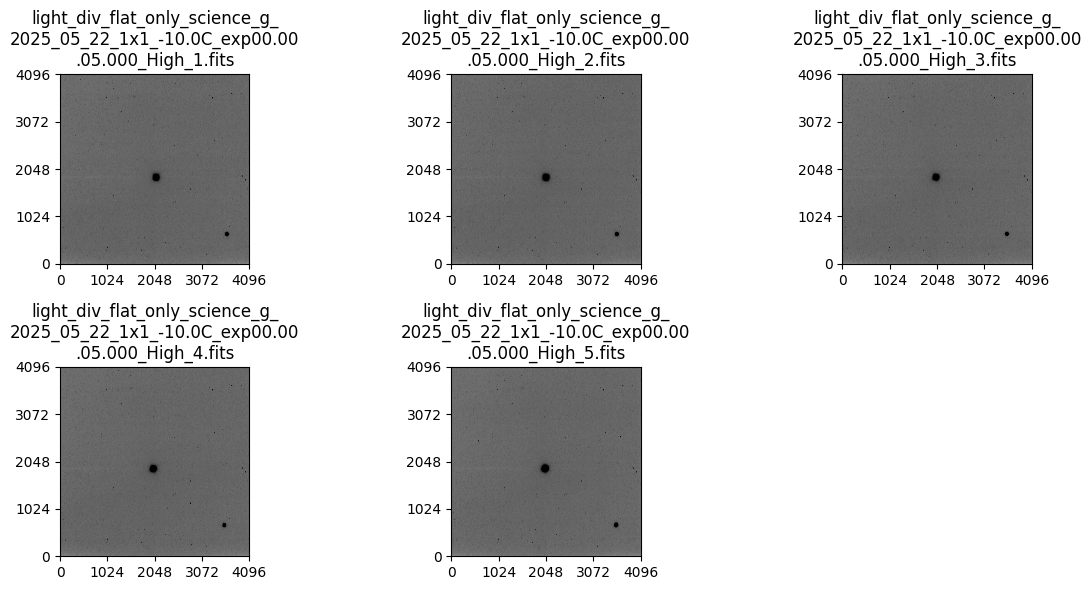

In [31]:
# Settings
font_size = 12
norm_percent = 99.0
cmap_choice = 'Greys'

# Find FITS files
images = sorted(glob.glob(os.path.join(images_dir, "*.fits")))
num_images = len(images)

# Subplot grid
num_cols = 3
num_rows = (num_images + num_cols - 1) // num_cols

# Calculate dynamic figsize
fig_width = 4 * num_cols
fig_height = 3 * num_rows

plt.figure(figsize=(fig_width, fig_height))

# Explicitly adjust subplot parameters
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.3)

for i, file in enumerate(images):
    try:
        image = fits.open(file, mode='readonly')
        header = image[0].header
        data = image[0].data

        # Apply BSCALE and BZERO
        bscale = header.get('BSCALE', 1.0)
        bzero = header.get('BZERO', 0.0)
        data = bscale * data + bzero

        # Handle NaN and Inf values
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        ax = plt.subplot(num_rows, num_cols, i + 1)
#        ax.set_xlabel("X [px]", fontdict={'fontsize': font_size})
#        ax.set_ylabel("Y [px]", fontdict={'fontsize': font_size})
        # Get the filename only
        filename = os.path.basename(file)

        # Wrap the filename to multiple lines if it's too long
        wrapped_title = '\n'.join([filename[i:i+30] for i in range(0, len(filename), 30)])

        # Set the wrapped title
        ax.set_title(wrapped_title, fontdict={'fontsize': font_size})

        
        ax.tick_params(axis='both', labelsize=10)

        # Calculate vmin and vmax based on percentiles
        vmin = np.percentile(data, 5)
        vmax = np.percentile(data, 95)

        # Normalize and display
        norm = simple_norm(data, 'sqrt', percent=norm_percent, vmin=vmin, vmax=vmax)
        ax.imshow(data, norm=norm, cmap=cmap_choice)

        # Set dynamic x and y labels
        ny, nx = data.shape
        ax.set_xticks(np.linspace(0, nx, 5))  # 5 ticks
        ax.set_yticks(np.linspace(0, ny, 5))
        ax.xaxis.set_major_formatter('{x:.0f}')
        ax.yaxis.set_major_formatter('{x:.0f}')

        image.close()
        gc.collect()

    except Exception as e:
        print(f"Error processing file {file}: {e}")

plt.tight_layout()
plt.show()

## Aperture Photometry

More information on aperture photometry using Photutils can be found here: [Aperture Photometry](https://photutils.readthedocs.io/en/stable/aperture.html)

First, we create a useful dictionary that contains: the sources detected using our finding algorithm ([DAOStarFinder](https://photutils.readthedocs.io/en/stable/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder)), the table with the aperture photometry results, and a final table with positions (both x,y and RA,Dec) instrumental magnitudes ad errors for the detected sources.

In [33]:
dict_aper = {}

# Let's assume you're working with a list of image filenames
for fname in images:  # 'images' is your list of FITS file paths
    key = os.path.basename(fname)  # Use filename as the key

    dict_aper[key] = {
        'sources found': None,
        'aperture phot table': None,
        'final aperture phot table': None
    }


### 1. Finding sources

[DAOStarFinder](https://photutils.readthedocs.io/en/stable/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder) detects stars in an image using the DAOFIND ([Stetson 1987](https://ui.adsabs.harvard.edu/abs/1987PASP...99..191S/abstract)) algorithm. DAOFIND searches images for local density maxima that have a peak amplitude greater than `threshold` (approximately; threshold is applied to a convolved image) and have a size and shape similar to the defined 2D Gaussian kernel.

**Note**: we adopted as Background estimator the function [MMMBackground](https://photutils.readthedocs.io/en/stable/api/photutils.background.MMMBackground.html#photutils.background.MMMBackground), which calculates the background in an array using the DAOPHOT MMM algorithm, on the whole image. 

When dealing with a variable background and/or the need to mask the regions where we have no data (for example, if we are analyzing an image with all the 4 NIRCam SW detectors, i.e. containing the chip gaps), we can set `var_bkg` = True and use a more complex algorithm that takes into account those issues.  

Note that the unit of the Level-2 and Level-3 Images from the pipeline is MJy/sr (hence a surface brightness). The actual unit of the image can be checked from the header keyword **BUNIT**. The scalar conversion constant is copied to the header keyword **PHOTMJSR**, which gives the conversion from DN/s to megaJy/steradian. For our analysis we revert back to DN/s.


In [38]:
def find_stars(image_path, image_index=0, var_bkg=False):
    """
    Opens a FITS image, subtracts background, finds stars, and stores result in dict_aper.
    """
    bkgrms = MADStdBackgroundRMS()
    mmm_bkg = MMMBackground()

    image = fits.open(image_path)
    data = image[0].data
    header = image[0].header
    image.close()

    filename = os.path.basename(image_path)
    print(f"Finding sources in image {image_index + 1}: {filename}\n")

    # PSF FWHM estimate (manual or from data)
    sigma_psf = 2.0  # pixels
    print(f"Assumed FWHM: {sigma_psf} px")

    if var_bkg:
        print("Using 2D Background subtraction")
        sigma_clip = SigmaClip(sigma=3.)
        coverage_mask = (data == 0)

        bkg = Background2D(data, (25, 25), filter_size=(3, 3), sigma_clip=sigma_clip,
                           bkg_estimator=mmm_bkg, coverage_mask=coverage_mask, fill_value=0.0)

        data_bkgsub = data - bkg.background
        _, _, std = sigma_clipped_stats(data_bkgsub)
    else:
        print("Using simple background subtraction")
        std = bkgrms(data)
        bkg = mmm_bkg(data)
        data_bkgsub = data - bkg

    # Star detection
    daofind = DAOStarFinder(threshold=10. * std, fwhm=sigma_psf,
                            roundhi=1.0, roundlo=-1.0, sharplo=0.30, sharphi=1.40)
    found_stars = daofind(data_bkgsub)

    # Store in dictionary
    dict_aper[filename] = {
        'sources found': found_stars,
        'aperture phot table': None,
        'final aperture phot table': None
    }

    print(f"\nNumber of sources found in the image: {len(found_stars) if found_stars is not None else 0}")
    print("-------------------------------------\n")

    return found_stars  # ✅ This line was missing


In [39]:
import time

tic = time.perf_counter()

for i, img in enumerate(images):  # 'images' is your list of FITS file paths
    sources_found = find_stars(image_path=img, image_index=i, var_bkg=False)

    if sources_found is not None:
        print(f"Found {len(sources_found)} stars in image {i+1}")
    else:
        print(f"No stars found in image {i+1}")

toc = time.perf_counter()

print("Elapsed Time for finding stars:", toc - tic)


Finding sources in image 1: light_div_flat_only_science_g_2025_05_22_1x1_-10.0C_exp00.00.05.000_High_1.fits

Assumed FWHM: 2.0 px
Using simple background subtraction

Number of sources found in the image: 14904
-------------------------------------

Found 14904 stars in image 1
Finding sources in image 2: light_div_flat_only_science_g_2025_05_22_1x1_-10.0C_exp00.00.05.000_High_2.fits

Assumed FWHM: 2.0 px
Using simple background subtraction

Number of sources found in the image: 14926
-------------------------------------

Found 14926 stars in image 2
Finding sources in image 3: light_div_flat_only_science_g_2025_05_22_1x1_-10.0C_exp00.00.05.000_High_3.fits

Assumed FWHM: 2.0 px
Using simple background subtraction

Number of sources found in the image: 14891
-------------------------------------

Found 14891 stars in image 3
Finding sources in image 4: light_div_flat_only_science_g_2025_05_22_1x1_-10.0C_exp00.00.05.000_High_4.fits

Assumed FWHM: 2.0 px
Using simple background subtracti

In [40]:
from astropy.nddata import block_reduce

def bin_image(data, bin_factor):
    """Bin an image by summing pixels in NxN blocks."""
    return block_reduce(data, (bin_factor, bin_factor), func=np.sum)


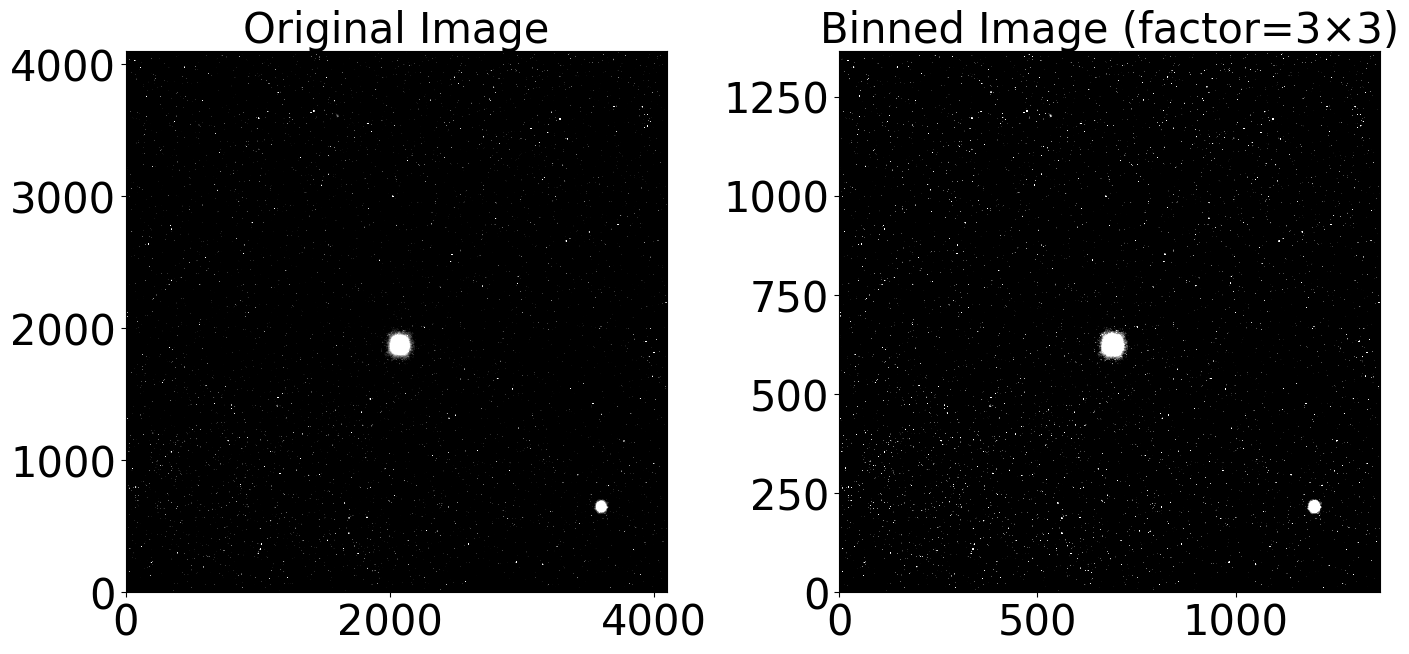

In [42]:

image_index = 0
image_path = images[image_index]  # 'images' is your list of FITS files

with fits.open(image_path) as hdul:
    image_data = hdul[0].data.astype(float)

# Define binning function (if not already defined)
def bin_image(image, bin_factor):
    shape = (image.shape[0] // bin_factor, bin_factor,
             image.shape[1] // bin_factor, bin_factor)
    return image[:shape[0]*bin_factor, :shape[2]*bin_factor].reshape(shape).mean(axis=(1, 3))

# Apply binning
bin_factor = 3
binned_data = bin_image(image_data, bin_factor)

# Plot original and binned images side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
ax1.imshow(image_data, cmap='Greys_r', origin='lower', vmin=0, vmax=np.percentile(image_data, 99))
ax1.set_title('Original Image')
ax2.imshow(binned_data, cmap='Greys_r', origin='lower', vmin=0, vmax=np.percentile(binned_data, 99))
ax2.set_title(f'Binned Image (factor={bin_factor}×{bin_factor})')
plt.tight_layout()
plt.show()


In [43]:
def find_stars_filtered(det, filt, image_index=0, var_bkg=False,
                        neighbor_check_radius=5,
                        neighbor_threshold_factor=0.3,
                        gaussian_smoothing_sigma=0.3):

    print(f"Finding sources on image {image_index+1}, filter '{filt}', detector '{det}':")

    # Get FWHM
    if filt not in dict_utils or 'psf fwhm' not in dict_utils[filt]:
        print(f"[ERROR] Missing filter info for {filt}")
        return None
    fwhm = dict_utils[filt]['psf fwhm']
    print(f"FWHM for the filter {filt}: {fwhm} px")

    # Load image
    image_path = dict_images[det][filt]['images'][image_index]
    with fits.open(image_path) as hdul:
        image_data = hdul[0].data.astype(float)

    # Background subtraction
    if var_bkg:
        bkg_path = dict_images[det][filt]['bkg'][0]
        with fits.open(bkg_path) as hdul_bkg:
            bkg_data = hdul_bkg[0].data.astype(float)
        image_data = image_data - bkg_data
    else:
        _, median, _ = sigma_clipped_stats(image_data, sigma=3.0)
        image_data = image_data - median

    # Clean data
    image_data = np.nan_to_num(image_data, nan=0.0, posinf=0.0, neginf=0.0)

    # Star detection
    _, _, std = sigma_clipped_stats(image_data, sigma=3.0)
    daofind = DAOStarFinder(fwhm=fwhm, threshold=5*std)
    sources_found = daofind(image_data)

#    # Neighborhood filter
#    filtered_stars = None
#    if sources_found is not None and len(sources_found) > 0:
#        x = sources_found['xcentroid']
#        y = sources_found['ycentroid']
#        good_stars = []

#        for k in range(len(sources_found)):
#            xc = int(np.round(x[k]))
#            yc = int(np.round(y[k]))

#            xmin = max(xc - neighbor_check_radius, 0)
#            xmax = min(xc + neighbor_check_radius + 1, image_data.shape[1])
#            ymin = max(yc - neighbor_check_radius, 0)
#            ymax = min(yc + neighbor_check_radius + 1, image_data.shape[0])

#            local_region = image_data[ymin:ymax, xmin:xmax]
#            central_value = image_data[yc, xc]
#            neighbor_values = local_region.flatten()
#            neighbor_values = neighbor_values[neighbor_values != central_value]

#            if np.any(neighbor_values > neighbor_threshold_factor * central_value):
#                good_stars.append(k)

#        filtered_stars = sources_found[good_stars]

    filtered_stars = sources_found

    # Store results
    dict_aper[det][filt]['sources found'] = filtered_stars
    if 'sources' not in dict_images[det][filt]:
        dict_images[det][filt]['sources'] = [None] * len(dict_images[det][filt]['images'])
    dict_images[det][filt]['sources'][image_index] = filtered_stars

    return filtered_stars


In [44]:

tic = time.perf_counter()

#th = [4.0, 4.0]  # threshold level for the two filters (length must match number of filters analyzed)

for det in dets_short:
    for j, filt in enumerate(filts_short):
        for i in np.arange(0, len(dict_images[det][filt]['images']), 1):

            # Use find_stars_filtered instead of find_stars
            sources_found = find_stars_filtered(det=det, filt=filt, image_index=i, var_bkg=False,
                                    neighbor_check_radius=10,
                                    neighbor_threshold_factor=0.3,
                                    gaussian_smoothing_sigma=0.3)

            # Optional: Do something with the found sources, e.g., print the number
            if sources_found is not None:
                print(f"Found {len(sources_found)} stars for det={det}, filt={filt}, image={i+1}")
            else:
                print(f"No stars found for det={det}, filt={filt}, image={i+1}")

toc = time.perf_counter()
#print("Elapsed Time for finding stars:", toc - tic)
#print(sources_found)  # This will show the table of detected stars

NameError: name 'dets_short' is not defined

In [13]:
## sources_found.sort('xcentroid')
# Long version of the list
sources_found.pprint(max_lines=-1, max_width=-1)
# Short version of the list
# print(sources_found)

 id     xcentroid          ycentroid           sharpness            roundness1             roundness2      npix        peak                flux                 mag              daofind_mag      
--- ------------------ ------------------ ------------------- ---------------------- --------------------- ---- ------------------ -------------------- ------------------- ----------------------
 19 23.093039673422634  501.0595093200408   0.881851383992806   -0.10541420640261613   -0.2502963845300158   25 11.707549139052695   14.875663983685655 -2.9311908995334015   -0.09638364528263477
 46 30.991759120644648 1186.0463060322672  0.9819090473339592    0.09870231412118512   -0.1541516078462381   25 17.997482310012224    5.866851264168948 -1.9210126954132147    -0.4675049654883024
 25   68.8690473808588  690.5631220583457  0.9915016511661255     0.7333428460736238     0.222217988758782   25 14.777015271273848     29.4864256731259 -3.6740553270628444   -0.20945974228075384
188  226.7904944386802 38

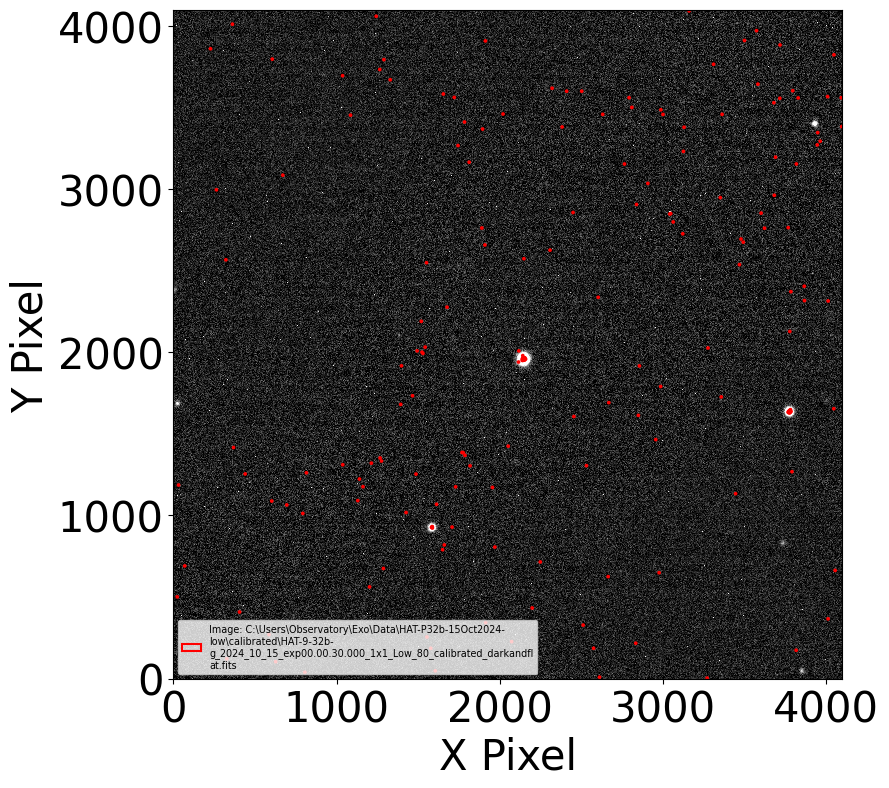

In [14]:
from photutils.aperture import CircularAperture
import textwrap

filtered_stars = dict_images[det][filt]['sources'][i]
image_path = dict_images[det][filt]['images'][i]
with fits.open(image_path) as hdul:
    image_data = hdul[0].data.astype(float)

# Wrap the path string into multiple lines (e.g., every 60 characters)
wrapped_path = "\n".join(textwrap.wrap(f"Image: {image_path}", width=60))

plt.figure(figsize=(9, 8))
plt.imshow(image_data, cmap='Greys_r', origin='lower', vmin=0, vmax=20, interpolation='nearest')

if filtered_stars is not None and len(filtered_stars) > 0:
    positions = np.transpose((filtered_stars['xcentroid'], filtered_stars['ycentroid']))
    apertures = CircularAperture(positions, r=5.)
    apertures.plot(color='red', lw=1.5)

#plt.title(f"{det}, {filt}, Frame {frame_index + 1}")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

# Multi-line legend with smaller font
plt.legend([wrapped_path], loc='lower left', fontsize='x-small', frameon=True)

plt.grid(False)
plt.tight_layout()
plt.show()

In [15]:
# This part Manually filters the lines I choose to keep from that list (basically sources that I can approve by eye as sources)

# Prompt the user for the indices of sources they want to keep
selected_indices = input("Enter the xcentroid values you want to keep (comma separated, e.g., 12.34, 23.45): ")

# Convert the input string into a list of floats
selected_xcentroids = [float(x) for x in selected_indices.split(',')]

# Filter the sources_found table to keep only rows with the specified xcentroids
selected_sources = sources_found[np.isin(sources_found['xcentroid'], selected_xcentroids)]

# Replace the sources_found object with the filtered sources
sources_found = selected_sources

# Print the new filtered sources table
print("\nFiltered sources table:")
sources_found.pprint(max_lines=-1, max_width=-1)


Enter the xcentroid values you want to keep (comma separated, e.g., 12.34, 23.45):  23.093039673422634



Filtered sources table:
 id     xcentroid          ycentroid         sharpness          roundness1           roundness2     npix        peak               flux                mag             daofind_mag     
--- ------------------ ----------------- ----------------- -------------------- ------------------- ---- ------------------ ------------------ ------------------- --------------------
 19 23.093039673422634 501.0595093200408 0.881851383992806 -0.10541420640261613 -0.2502963845300158   25 11.707549139052695 14.875663983685655 -2.9311908995334015 -0.09638364528263477


In [ ]:
# Next time continue from here. Open the above image in ds9 check for the 3 stars locations you want to stick to. make a list out of them and then input that list for the next piece of code.

### 2. Aperture Photometry

In the function below that allows to perform aperture photometry, we need to specify 4 parameters: the filter (i.e., image) used in the analysis, the aperture radius and the inner and outer radii for the annulus used to determine the local background. Values for the aperture radius and the annulii depend on the adopted filter and the user science case.

Note that Aperture object support multiple positions, allowing to perform photometry in [multiple apertures](https://photutils.readthedocs.io/en/latest/aperture.html#multiple-apertures-at-each-position) at each position. For multiple apertures, the output table column names are appended with the positions index.

In [41]:
def aperture_phot(det=det, filt=filt, radius=[3.5], sky_in=7, sky_out=10):

    positions = np.transpose((dict_aper[det][filt]['sources found']['xcentroid'],
                              dict_aper[det][filt]['sources found']['ycentroid']))

    image = fits.open(dict_images[det][filt]['images'][0])
    data_sb = image[0].data
    imh = image[0].header
    data = data_sb
#    data = data_sb / imh['PHOTMJSR']
    aa = np.argwhere(data < 0)

    for i in np.arange(0, len(aa), 1):
        data[aa[i][0], aa[i][1]] = 0

    error = np.sqrt(data)

    tic = time.perf_counter()

    table_aper = Table()

    for rad in radius:
        print("Performing aperture photometry for filter {1}; radius r = {0} px".format(rad, filt))
        rr = str(rad)
        aperture = CircularAperture(positions, r=rad)
#        print("Positions being used for photometry:\n", positions)

        
        annulus_aperture = CircularAnnulus(positions, r_in=sky_in, r_out=sky_out)
        annulus_mask = annulus_aperture.to_mask(method='center')

        bkg_median = []
        bkg_stdev = []
        for mask in annulus_mask:
            annulus_data = mask.multiply(data)
            annulus_data_1d = annulus_data[mask.data > 0]
            _, median_sigclip, stdev_sigclip = sigma_clipped_stats(annulus_data_1d)
            bkg_median.append(median_sigclip)
            bkg_stdev.append(stdev_sigclip)
        bkg_median = np.array(bkg_median)
        bkg_stdev = np.array(bkg_stdev)

        phot = aperture_photometry(data, aperture, method='exact', error=error)

        phot['annulus_median'] = bkg_median
        phot['aper_bkg'] = bkg_median * aperture.area
        phot['aper_sum_bkgsub'] = phot['aperture_sum'] - phot['aper_bkg']

        # Create a temporary table for this radius's data
        temp_table = Table()
        temp_table['aper_sum_' + rr + 'px'] = phot['aperture_sum']
        temp_table['annulus_median_' + rr + 'px'] = phot['annulus_median']
        temp_table['aper_bkg_' + rr + 'px'] = phot['aper_bkg']
        temp_table['aper_sum_bkgsub_' + rr + 'px'] = phot['aper_sum_bkgsub']

        error_poisson = phot['aperture_sum_err']
        error_scatter_sky = aperture.area * bkg_stdev**2
        error_mean_sky = bkg_stdev**2 * aperture.area**2 / annulus_aperture.area

        fluxerr = np.sqrt(error_poisson + error_scatter_sky + error_mean_sky)
        temp_table['flux_err_' + rr + 'px'] = fluxerr

        # Add the temporary table's columns to the main table
        if dict_aper[det][filt]['aperture phot table'] is None:
            dict_aper[det][filt]['aperture phot table'] = temp_table  # Create table on first pass
        else:
            for col in temp_table.colnames:
                dict_aper[det][filt]['aperture phot table'][col] = temp_table[col] # Add on subsequent passes

    print(f"Shape of aperture photometry table for det {det}, filt {filt}: Rows={len(dict_aper[det][filt]['aperture phot table'])}, Columns={len(dict_aper[det][filt]['aperture phot table'].colnames)}")
    print(dict_aper[det][filt]['aperture phot table'].colnames)

    toc = time.perf_counter()
    print("Time Elapsed:", toc - tic)
    # import csv
    # with open('my_data.csv', 'w', newline='') as csvfile:
    #     writer = csv.writer(csvfile)
    #     writer.writerows(phot)

    return

In [42]:
det = 'NRCB1'
filt1 = 'F070W'
#filt2 = 'F335M'

## What Radius to choose? Set the radius to be 1.5 to 2 times the FWHM found by find_stars in two steps higher.
##  Set sky_in to be significantly larger than the aperture radius (at least 2-3 times the radius). 
## Guideline: Set sky_out to be a few pixels larger than sky_in. This provides a reasonable area for estimating 
## the sky background. A difference of 3-5 pixels is usually sufficient.
aperture_phot(det=det, filt=filt1, radius=[6.0], sky_in=18, sky_out=23)
#aperture_phot(det=det, filt=filt2, radius=[4.0], sky_in=6, sky_out=9)

print("\nFinal Aperture Photometry Table:")
phot_table = dict_aper[det][filt1]['aperture phot table']

# Print Header (Column Names)
print("  Source  | " + " | ".join(phot_table.colnames) + " |")
print("----------" + "---" * len(phot_table.colnames))  # Separator line

# Print Data Rows
for i in range(len(phot_table)):
    row_values = " | ".join(str(val) for val in phot_table[i].values())
    print(f"  {i+1:6d}  | {row_values} |")


Performing aperture photometry for filter F070W; radius r = 6.0 px
Shape of aperture photometry table for det NRCB1, filt F070W: Rows=192, Columns=5
['aper_sum_6.0px', 'annulus_median_6.0px', 'aper_bkg_6.0px', 'aper_sum_bkgsub_6.0px', 'flux_err_6.0px']
Time Elapsed: 0.11501700012013316

Final Aperture Photometry Table:
  Source  | aper_sum_6.0px | annulus_median_6.0px | aper_bkg_6.0px | aper_sum_bkgsub_6.0px | flux_err_6.0px |
-------------------------
       1  | 210.09396585020514 | 0.0 | 0.0 | 210.09396585020514 | 11.962173036840754 |
       2  | 240.6871583254822 | 0.4093405879106573 | 46.295329816664925 | 194.39182850881727 | 15.550617110942293 |
       3  | 287.569361235909 | 2.029603442351963 | 229.54274151096536 | 58.02661972494366 | 19.481385058514405 |
       4  | 263.65472242294425 | 1.994109821900885 | 225.52850760966257 | 38.12621481328168 | 19.528592298878984 |
       5  | 274.4680314730491 | 1.8461618478337716 | 208.79598594572403 | 65.67204552732508 | 20.139073152145258

### 3. Table with magnitudes and positions

We create the final tables containing positions, magnitudes and errors for each catalog

In [50]:
## Please pay attention that the magnitude reported at this stage is the instrumental magnitude which refers to a
## magnitude value that hasn’t been calibrated to a standard system. It’s the raw magnitude derived directly from the instrument’s measurements.
## Instrumental magnitudes are specific to the telescope, instrument, and observing conditions. They need to be corrected for things like atmospheric
## extinction, instrument sensitivity, and zero points to be converted to standard magnitudes (e.g., AB magnitudes, Vega magnitudes)

radii = [6.0]  # Define a list of aperture radii to use (currently only one radius)
print_image_index = 0  # Define the index of the image for which to print the final table
final_table_phot = None  # Initialize a variable to store the final photometry table for the selected image

# Loop through each detector in the 'dets_short' list
for det in dets_short:
    # Loop through each filter in the 'filts_short' list
    for j, filt in enumerate(filts_short):
        # Loop through each image associated with the current detector and filter
        for i in np.arange(0, len(dict_images[det][filt]['images']), 1):

            radius = str(radii[j])  # Get the aperture radius for the current filter (converted to string for table column names)

            image = fits.open(dict_images[det][filt]['images'][0])  # Open the FITS image file 
            data = image[0].data  # Extract the image data from the FITS file

            # Create a mask to select valid sources for photometry
            mask = ((dict_aper[det][filt]['sources found']['xcentroid'] > 0) &  # Ensure x-coordinates are positive
                    (dict_aper[det][filt]['sources found']['xcentroid'] < data.shape[1]) &  # Ensure x-coordinates are within image bounds
                    (dict_aper[det][filt]['sources found']['ycentroid'] > 0) &  # Ensure y-coordinates are positive
                    (dict_aper[det][filt]['sources found']['ycentroid'] < data.shape[0]) &  # Ensure y-coordinates are within image bounds
                    (dict_aper[det][filt]['aperture phot table']['aper_sum_bkgsub_' + radius + 'px'] > 0))  # Ensure background-subtracted aperture sum is positive

            table_phot = Table()  # Create a new table to store the photometry results for the current image

            table_phot['x'] = dict_aper[det][filt]['sources found']['xcentroid'][mask]  # Store the x-coordinates of the selected sources
            table_phot['y'] = dict_aper[det][filt]['sources found']['ycentroid'][mask]  # Store the y-coordinates of the selected sources

## I don't have the wcs information so I am ignoring the following line for now.
#            ra, dec = image_model.meta.wcs(table_phot['x'], table_phot['y'])
            # Calculate instrumental magnitudes and their errors
            table_phot[filt + '_inst'] = -2.5 * np.log10(dict_aper[det][filt]['aperture phot table']['aper_sum_bkgsub_' + radius + 'px'][mask])  # Calculate instrumental magnitude
            table_phot['e' + filt + '_inst'] = 1.086 * (dict_aper[det][filt]['aperture phot table']['flux_err_' + radius + 'px'][mask] /
                                                        dict_aper[det][filt]['aperture phot table']['aper_sum_bkgsub_' + radius + 'px'][mask])  # Calculate instrumental magnitude error

            dict_aper[det][filt]['final aperture phot table'] = table_phot  # Store the photometry table in the 'dict_aper' dictionary
#            print(table_phot)  #Print the entire table

            # Store the table for the specified image for printing at the end:
            if i == print_image_index:
                final_table_phot = table_phot

# Using this sorted table I hope to be able to filter out 
if final_table_phot is not None:
    print(f"Table for image index {print_image_index} (sorted by xcentroid):")
    final_table_phot.sort('x')  # Sort the table in place by 'x' (assuming xcentroid is 'x')
    print(final_table_phot)
else:
    print(f"No table found for image index {print_image_index}.")

#print(table_phot[3])

Table for image index 0 (sorted by xcentroid):
        x                  y               F070W_inst         eF070W_inst    
------------------ ------------------ ------------------- -------------------
23.093039673422634  501.0595093200408 -2.7795748268275773  1.6928962295123355
30.991759120644648 1186.0463060322672  -4.595661365379379    0.29759269226891
  68.8690473808588  690.5631220583457 -4.1870002607159105 0.45179424096619064
 226.7904944386802 3858.9717116504066   -4.23410730209493 0.37479579226383547
263.10159809418207   2994.82169375006 -3.3156757735906854  0.8876722341159246
321.01702412015493 2565.9651121085526  -3.176015330868567  1.0861280075782156
326.98624916303936  121.7660684802232   -4.04486394021128  0.5242322862380658
 361.1445007417723  4009.455799985508 -3.4278679285541855  0.7848760443719818
 367.8973078963212 1415.9440808243535 -3.6987331701542834  0.6735760797147144
 404.7791963535693  408.1993471985315   -4.07980235408029  0.5067596350388144
 439.118971099157

### Matched sources Table

We cross-match the catalogs to obtain the single color-magnitude diagram.

Stars from the two filters are associated if the distance between the matches is < 0.5 px. 